# Análise de Resultados (19/04 até 25/04)

Este notebook foca nos experimentos realizados a partir do dia 19 de abril de 2026.

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

sns.set_theme(style="whitegrid")

In [26]:
def load_recent_results(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    data = []
    for line in lines[1:]:
        line = line.strip()
        if not line: continue
        
        if '2026-04-19' in line or '2026-04-20' in line or '2026-04-21' in line or \
           '2026-04-22' in line or '2026-04-23' in line or '2026-04-24' in line or '2026-04-25' in line:
            
            parts = line.split(';') if ';' in line else line.split(',')
            
            def parse_metric(val):
                val = str(val).strip()
                if val.count('.') > 1: 
                    return float(val.replace('.', '')) / 1e16
                try:
                    return float(val)
                except ValueError:
                    return None

            row = {
                'model': parts[0],
                'scenario': parts[1],
                'smote': str(parts[2]).lower() == 'true',
                'roc_auc': parse_metric(parts[3]), 
                'f1': parse_metric(parts[4]),
                'accuracy': parse_metric(parts[5]),
                'n_features': int(parts[6]),
                'timestamp': parts[-1]
            }
            data.append(row)
            
    return pd.DataFrame(data)

df = load_recent_results('experiments.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

print(f"Total de experimentos desde 19/04: {len(df)}")
df.head()

Total de experimentos desde 19/04: 36


,model,scenario,smote,roc_auc,f1,accuracy,n_features,timestamp
0,DecisionTree,sem_submodalidade,False,0.794122,0.833502,0.801533,67,2026-04-19 12:13:21.634496
1,DecisionTree,sem_submodalidade,True,0.792308,0.829899,0.798430,67,2026-04-19 12:13:29.298881
2,DecisionTree,submodalidade_agrupada,False,0.814115,0.849582,0.820734,97,2026-04-19 12:13:34.142054
3,DecisionTree,submodalidade_agrupada,True,0.813561,0.847827,0.819328,97,2026-04-19 12:13:43.373674
4,DecisionTree,submodalidade_engineered,False,0.794122,0.833502,0.801533,67,2026-04-19 12:13:47.595881


## Melhores Resultados por Métrica

In [27]:
metrics = ['roc_auc', 'f1', 'accuracy']
for metric in metrics:
    if not df[metric].dropna().empty:
        best = df.loc[df[metric].idxmax()]
        print(f"Melhor {metric.upper()}: {best[metric]:.4f} | Modelo: {best['model']} | Cenário: {best['scenario']} | SMOTE: {best['smote']}")

Melhor ROC_AUC: 0.9444 | Modelo: XGBoost | Cenário: submodalidade_agrupada | SMOTE: False
Melhor F1: 0.8864 | Modelo: XGBoost | Cenário: submodalidade_agrupada | SMOTE: False
Melhor ACCURACY: 0.8672 | Modelo: XGBoost | Cenário: submodalidade_agrupada | SMOTE: False


## Comparação de Modelos

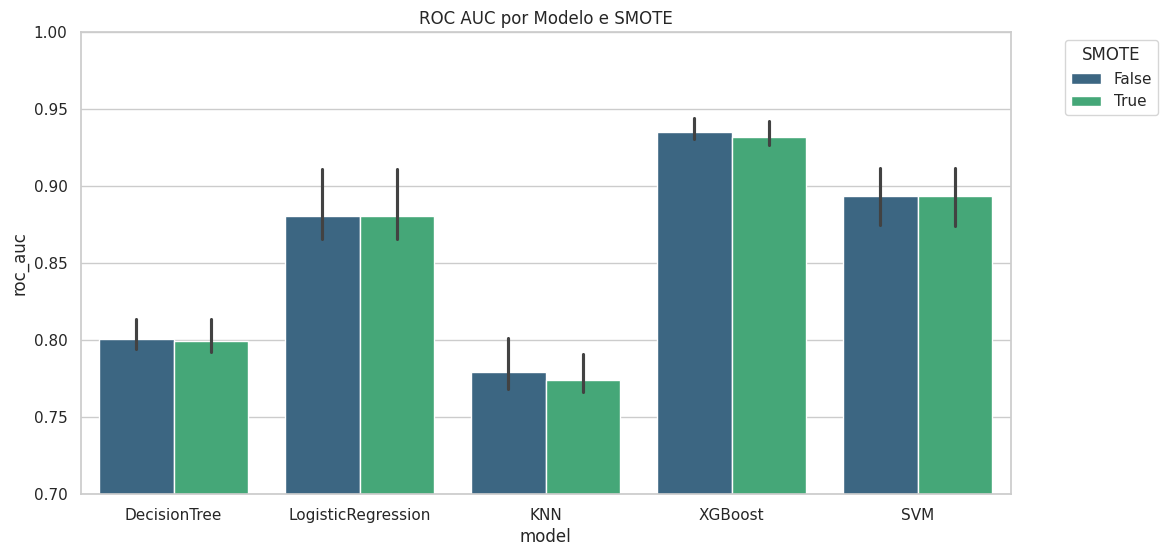

In [28]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='model', y='roc_auc', hue='smote', palette='viridis')
plt.title('ROC AUC por Modelo e SMOTE')
plt.ylim(0.7, 1.0)
plt.legend(title='SMOTE', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

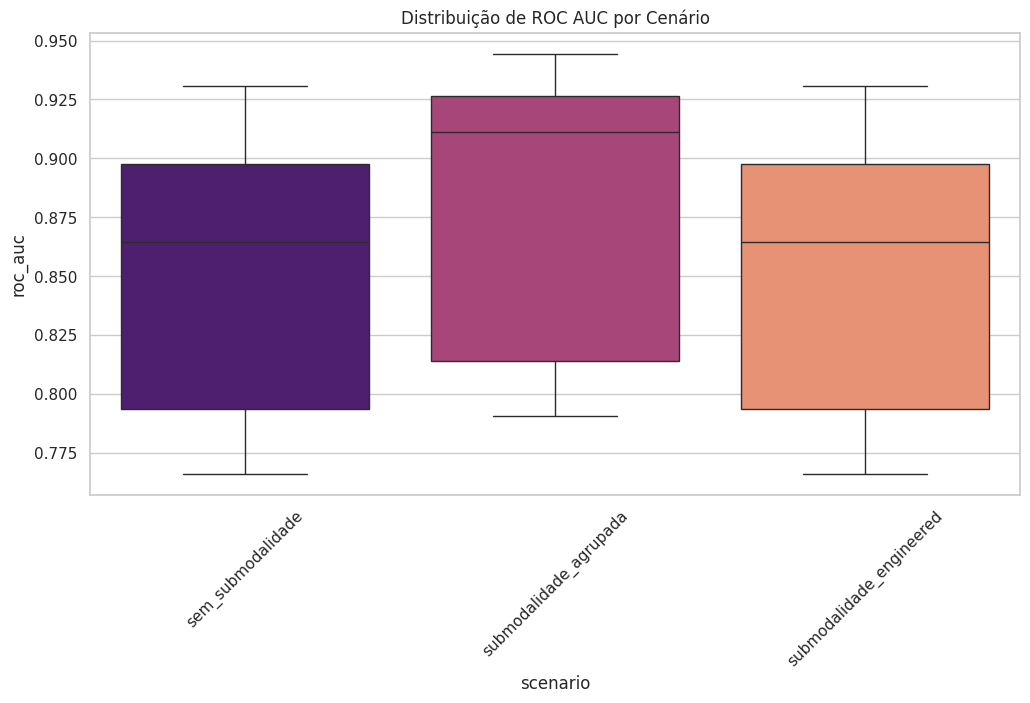

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='scenario', y='roc_auc', palette='magma', hue='scenario', legend=False)
plt.title('Distribuição de ROC AUC por Cenário')
plt.xticks(rotation=45)
plt.show()

## Tabela Completa de Resultados (Estilizada)

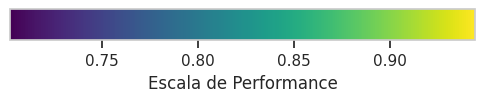

,model,scenario,smote,roc_auc,f1,accuracy,n_features,timestamp
20,XGBoost,submodalidade_agrupada,False,0.944406,0.886405,0.867184,97,2026-04-19 15:28:33.715887
21,XGBoost,submodalidade_agrupada,True,0.942460,0.884649,0.865943,97,2026-04-19 15:28:40.011706
22,XGBoost,submodalidade_engineered,False,0.930859,0.872587,0.851962,67,2026-04-19 15:28:42.400405
18,XGBoost,sem_submodalidade,False,0.930859,0.872587,0.851962,67,2026-04-19 15:28:24.803468
23,XGBoost,submodalidade_engineered,True,0.926829,0.867960,0.847673,67,2026-04-19 15:28:47.938035
19,XGBoost,sem_submodalidade,True,0.926829,0.867960,0.847673,67,2026-04-19 15:28:30.744369
26,SVM,submodalidade_agrupada,False,0.926492,0.861069,0.844607,97,2026-04-19 22:10:09.328083
27,SVM,submodalidade_agrupada,True,0.926482,0.863067,0.846322,97,2026-04-20 00:25:56.763491
8,LogisticRegression,submodalidade_agrupada,False,0.911407,0.847559,0.829969,97,2026-04-19 12:29:06.686764
9,LogisticRegression,submodalidade_agrupada,True,0.911388,0.849011,0.831046,97,2026-04-19 12:29:15.394672


In [30]:
all_metrics = df[['roc_auc', 'f1', 'accuracy']].values
norm = mpl.colors.Normalize(vmin=np.nanmin(all_metrics), vmax=np.nanmax(all_metrics))
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)

fig, ax = plt.subplots(figsize=(6, 0.4))
fig.colorbar(sm, cax=ax, orientation='horizontal', label='Escala de Performance')
plt.show()

df.sort_values(by='roc_auc', ascending=False).style.background_gradient(subset=['roc_auc', 'f1', 'accuracy'], cmap='viridis')

## Análise - model_results.csv (Recentes)

In [31]:
import pandas as pd
import os

if os.path.exists('model_results.csv'):
    df_models = pd.read_csv('model_results.csv', sep=';')
    df_models['timestamp'] = pd.to_datetime(df_models['timestamp'])
    
    # Filtrando por data
    df_models_filtered = df_models[df_models['timestamp'] >= '2026-04-19'].copy()
    
    # Pegando apenas a fase de teste
    df_test = df_models_filtered[df_models_filtered['phase'] == 'test'].copy()
    
    print(f"Total de resultados de teste em model_results.csv (Recentes): {len(df_test)}")
    
    if not df_test.empty:
        # Removendo colunas desnecessárias ou formatando
        display(df_test.sort_values(by='roc_auc', ascending=False).style.background_gradient(subset=['roc_auc', 'f1', 'accuracy'], cmap='viridis'))
else:
    print("Arquivo model_results.csv não encontrado.")


Total de resultados de teste em model_results.csv (Recentes): 12


,model,scenario,smote,phase,roc_auc,f1,accuracy,best_params,timestamp
21,RandomForest,sem_submodalidade,False,test,0.932190,0.874057,0.853732,"{'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 200, 'smote': 'passthrough'}",2026-04-19 12:45:44.315994
19,RandomForest,sem_submodalidade,True,test,0.930803,0.868414,0.850173,"{'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 200, 'smote': SMOTE(random_state=42)}",2026-04-19 12:45:36.419460
29,XGBoost,sem_submodalidade,False,test,0.930373,0.864766,0.848184,"{'smote': 'passthrough', 'xgb__colsample_bytree': 1, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 400, 'xgb__subsample': 0.8}",2026-04-19 15:36:31.075131
27,XGBoost,sem_submodalidade,True,test,0.925956,0.858277,0.842252,"{'smote': SMOTE(random_state=42), 'xgb__colsample_bytree': 1, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 400, 'xgb__subsample': 0.8}",2026-04-19 15:36:28.341003
13,DecisionTree,sem_submodalidade,False,test,0.910683,0.854567,0.830973,"{'dt__criterion': 'entropy', 'dt__max_depth': 10, 'dt__min_samples_leaf': 4, 'dt__min_samples_split': 10, 'smote': 'passthrough'}",2026-04-19 12:24:12.607259
11,DecisionTree,sem_submodalidade,True,test,0.907896,0.831701,0.817412,"{'dt__criterion': 'entropy', 'dt__max_depth': 10, 'dt__min_samples_leaf': 4, 'dt__min_samples_split': 10, 'smote': SMOTE(random_state=42)}",2026-04-19 12:24:10.931818
15,LogisticRegression,sem_submodalidade,True,test,0.865685,0.810887,0.791513,"{'lr__C': 10, 'lr__solver': 'lbfgs', 'smote': SMOTE(random_state=42)}",2026-04-19 12:30:33.725433
17,LogisticRegression,sem_submodalidade,False,test,0.865526,0.810565,0.791203,"{'lr__C': 10, 'lr__solver': 'lbfgs', 'smote': 'passthrough'}",2026-04-19 12:30:37.751483
31,SVM,sem_submodalidade,True,test,0.864030,0.804102,0.785910,"{'smote': SMOTE(random_state=42), 'svc__C': 10}",2026-04-25 15:28:20.151183
33,SVM,sem_submodalidade,False,test,0.863847,0.804301,0.786074,"{'smote': 'passthrough', 'svc__C': 10}",2026-04-25 15:28:32.262749
